In [ ]:
# Imports and configuration

from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
TEST_SIZE = 0.20  # internal split of the TRAINING pool only (for grid-search evaluation)
# NOTE: this notebook trains on nsl_detector_train + unsw_portion1 fingerprints only.


FINGERPRINT_ROOT = Path("model_outputs")
DETECTOR_OUTPUT_DIR = Path("model_outputs/detector_models")
DETECTOR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = ["confidence", "entropy", "margin"]

MODEL_CONFIGS = {
    "logistic_regression": {
        "display_name": "Logistic Regression",
        "folder": "logistic_regression_fingerprints",
    },
    "svm": {
        "display_name": "SVM",
        "folder": "svm_fingerprints",
    },
    "mlp": {
        "display_name": "MLP",
        "folder": "mlp_fingerprints",
    },
}

In [ ]:
#  Helper function to load and label fingerprints

def load_detector_dataset(model_name):
    """Load NSL and UNSW fingerprints and create Layer 2 labels."""

    config = MODEL_CONFIGS[model_name]
    fingerprint_dir = FINGERPRINT_ROOT / config["folder"]

    nsl_path = fingerprint_dir / "nsl_detector_train_fingerprints.csv"
    unsw_path = fingerprint_dir / "unsw_portion1_fingerprints.csv"

    if not nsl_path.exists():
        raise FileNotFoundError(f"Missing file: {nsl_path}")

    if not unsw_path.exists():
        raise FileNotFoundError(f"Missing file: {unsw_path}")

    nsl_df = pd.read_csv(nsl_path)
    unsw_df = pd.read_csv(unsw_path)

    required_columns = set(FEATURE_COLUMNS)
    missing_nsl = required_columns - set(nsl_df.columns)
    missing_unsw = required_columns - set(unsw_df.columns)

    if missing_nsl:
        raise ValueError(
            f"{nsl_path} is missing columns: {sorted(missing_nsl)}"
        )

    if missing_unsw:
        raise ValueError(
            f"{unsw_path} is missing columns: {sorted(missing_unsw)}"
        )

    # Layer 2 target:
    # 0 = Trustworthy / in-distribution
    # 1 = Suspicious / out-of-distribution
    nsl_df = nsl_df.copy()
    unsw_df = unsw_df.copy()

    nsl_df["detector_label"] = 0
    unsw_df["detector_label"] = 1

    nsl_df["source_dataset"] = "NSL-KDD"
    unsw_df["source_dataset"] = "UNSW-NB15"

    detector_df = pd.concat(
        [nsl_df, unsw_df],
        ignore_index=True
    )

    if detector_df[FEATURE_COLUMNS].isna().any().any():
        raise ValueError("Fingerprint features contain missing values.")

    return detector_df

In [ ]:
# nspect the three detector datasets

detector_datasets = {}

for model_name, config in MODEL_CONFIGS.items():
    detector_df = load_detector_dataset(model_name)
    detector_datasets[model_name] = detector_df

    print(f"\n{config['display_name']}")
    print("Dataset shape:", detector_df.shape)
    print("\nDetector-label distribution:")
    print(
        detector_df["detector_label"]
        .value_counts()
        .sort_index()
        .rename(index={0: "Trustworthy", 1: "Suspicious"})
    )


Logistic Regression
Dataset shape: (47340, 7)

Detector-label distribution:
detector_label
Trustworthy    15780
Suspicious     31560
Name: count, dtype: int64

SVM
Dataset shape: (47340, 7)

Detector-label distribution:
detector_label
Trustworthy    15780
Suspicious     31560
Name: count, dtype: int64

MLP
Dataset shape: (47340, 7)

Detector-label distribution:
detector_label
Trustworthy    15780
Suspicious     31560
Name: count, dtype: int64


In [46]:
#  full fingerprint dataframe (all columns: true_label, predicted_label, confidence, entropy, margin, 
# detector_label, source_dataset)
detector_datasets["logistic_regression"].head()  

,true_label,predicted_label,confidence,entropy,margin,detector_label,source_dataset
0,0,0,0.934752,0.241170,0.869504,0,NSL-KDD
1,0,0,0.969739,0.135649,0.939477,0,NSL-KDD
2,0,0,0.988263,0.063840,0.976525,0,NSL-KDD
3,0,0,0.990801,0.052288,0.981602,0,NSL-KDD
4,0,0,0.934755,0.241161,0.869510,0,NSL-KDD


In [47]:
# only the 3 features actually used to train the Layer 2 detector (confidence, entropy, margin)            #    
detector_datasets["logistic_regression"][FEATURE_COLUMNS].head()    

,confidence,entropy,margin
0,0.934752,0.241170,0.869504
1,0.969739,0.135649,0.939477
2,0.988263,0.063840,0.976525
3,0.990801,0.052288,0.981602
4,0.934755,0.241161,0.869510


In [48]:
# missing values
for model_name, detector_df in detector_datasets.items():
    total_missing = detector_df.isnull().sum().sum()

    print(f"{model_name}: {total_missing} missing values")

logistic_regression: 0 missing values
svm: 0 missing values
mlp: 0 missing values


In [49]:
# Duplicate rows
detector_df.duplicated().sum()

# Infinite values
import numpy as np
np.isinf(detector_df[["confidence", "entropy", "margin"]]).sum()

confidence    0
entropy       0
margin        0
dtype: int64

In [50]:
for model_name, detector_df in detector_datasets.items():
    print(f"{model_name}: {detector_df.shape}")

logistic_regression: (47340, 7)
svm: (47340, 7)
mlp: (47340, 7)


In [51]:
# Summary Statistics
fingerprint_features = ["confidence", "entropy", "margin"]

for model_name, detector_df in detector_datasets.items():
    print()
    print(f"{model_name.upper()} - Summary Statistics")
    print()

    display(detector_df[fingerprint_features].describe().T)


LOGISTIC_REGRESSION - Summary Statistics



,count,mean,std,min,25%,50%,75%,max
confidence,47340.0,0.755904,0.178284,0.500115,0.559138,0.850098,0.906620,0.998869
entropy,47340.0,0.460967,0.218972,0.008800,0.310289,0.422540,0.686136,0.693147
margin,47340.0,0.511807,0.356567,0.000231,0.118276,0.700195,0.813240,0.997739



SVM - Summary Statistics



,count,mean,std,min,25%,50%,75%,max
confidence,47340.0,0.892953,0.112342,5.000000e-01,0.794757,0.938316,0.981041,1.000000
entropy,47340.0,0.273935,0.218557,2.410403e-10,0.093961,0.231577,0.507585,0.693147
margin,47340.0,0.785905,0.224684,0.000000e+00,0.589515,0.876631,0.962082,1.000000



MLP - Summary Statistics



,count,mean,std,min,25%,50%,75%,max
confidence,47340.0,0.889387,0.135592,5.000740e-01,0.811395,0.949232,0.999724,1.000000
entropy,47340.0,0.253352,0.248745,2.763102e-11,0.002538,0.200772,0.484194,0.693147
margin,47340.0,0.778773,0.271183,1.480579e-04,0.622790,0.898463,0.999448,1.000000


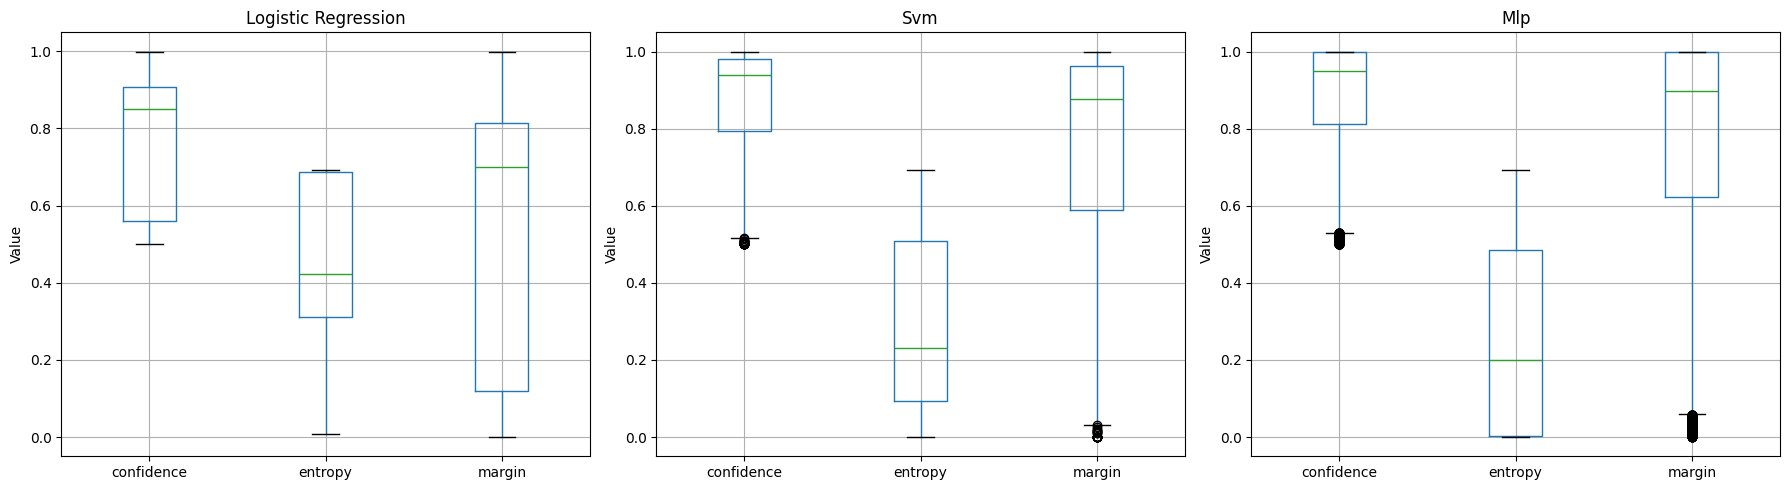

In [52]:
# Boxplots (Outlier Inspection)
import matplotlib.pyplot as plt

fingerprint_features = ["confidence", "entropy", "margin"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, detector_df) in zip(axes, detector_datasets.items()):
    detector_df[fingerprint_features].boxplot(ax=ax)
    ax.set_title(model_name.replace("_", " ").title())
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

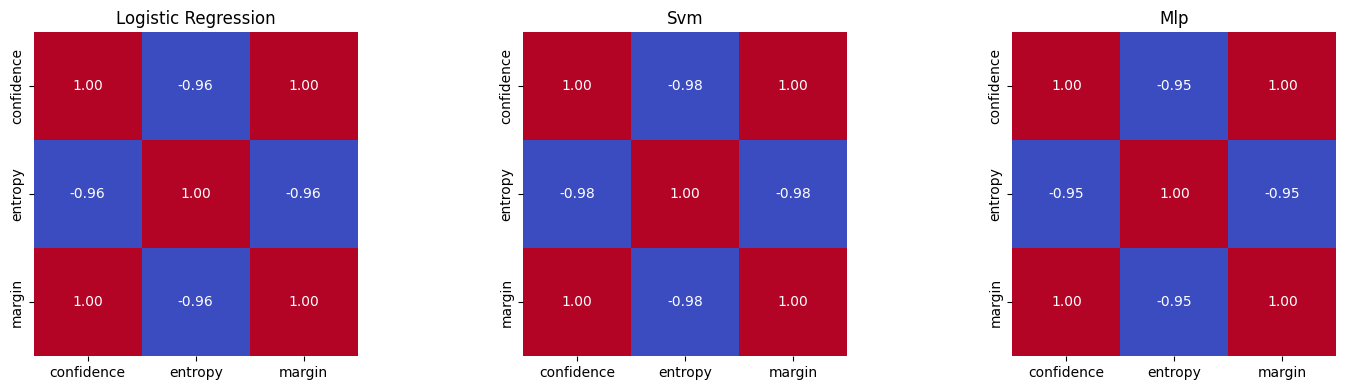

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

fingerprint_features = ["confidence", "entropy", "margin"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, detector_df) in zip(axes, detector_datasets.items()):
    corr = detector_df[fingerprint_features].corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        square=True,
        ax=ax,
        cbar=False
    )

    ax.set_title(model_name.replace("_", " ").title())

plt.tight_layout()
plt.show()

In [ ]:
# Train and save one Decision Tree detector

# UNSW contains many more samples than NSL-KDD.
# class_weight="balanced" reduces the effect of this class imbalance.

def train_detector(model_name, detector_df):
    """Tune, train, and save the best Decision Tree detector."""

    display_name = MODEL_CONFIGS[model_name]["display_name"]

    X = detector_df[FEATURE_COLUMNS]
    y = detector_df["detector_label"]

    # 20% separate for internal evaluation / model selection only.
  
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    print(X_train.head()) 

    detector = DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )

    param_grid = {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 10, 50],
        "min_samples_leaf": [1, 5, 20],
        "criterion": ["gini", "entropy"],
    }

    grid = GridSearchCV(
        estimator=detector,
        param_grid=param_grid,
        scoring="f1",
        cv=5,
        n_jobs=-1,
        verbose=1,
    )

    # Hyperparameter tuning is performed only on the training portion.
    grid.fit(X_train, y_train)

    best_detector = grid.best_estimator_

    # Main Layer 2 output folder
    DETECTOR_OUTPUT_DIR = Path("detector_model_outputs")
    DETECTOR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Separate folder for the current detector
    model_dir = DETECTOR_OUTPUT_DIR / f"{model_name}_detector"
    model_dir.mkdir(parents=True, exist_ok=True)

    # Save the best trained detector
    joblib.dump(
        best_detector,
        model_dir / f"best_{model_name}_detector.joblib",
    )

    # Save the untouched evaluation split
    np.save(
        model_dir / f"{model_name}_X_test.npy",
        X_test.to_numpy(),
    )

    np.save(
        model_dir / f"{model_name}_y_test.npy",
        y_test.to_numpy(),
    )

    print()
    print(f"{display_name} — Decision Tree Detector")
    print()
    print("Best parameters:", grid.best_params_)
    print("Best cross-validation F1:", grid.best_score_)
    print("Training samples:", len(X_train))
    print("Reserved evaluation samples:", len(X_test))
    print(
        "Saved model:",
        model_dir / f"best_{model_name}_detector.joblib",
    )

    return {
        "model": best_detector,
        "best_parameters": grid.best_params_,
        "best_cv_f1": grid.best_score_,
        "X_test": X_test,
        "y_test": y_test,
    }

In [7]:
detector_results = {}

for model_name, detector_df in detector_datasets.items():
    detector_results[model_name] = train_detector(
        model_name=model_name,
        detector_df=detector_df,
    )

       confidence   entropy    margin
9864     0.937494  0.233807  0.874989
2680     0.832419  0.452029  0.664838
18849    0.510829  0.692913  0.021657
20520    0.873808  0.379083  0.747616
5211     0.896176  0.333405  0.792352
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Logistic Regression — Decision Tree Detector

Best parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation F1: 0.975789909283342
Training samples: 37872
Reserved evaluation samples: 9468
Saved model: detector_model_outputs/logistic_regression_detector/best_logistic_regression_detector.joblib
       confidence   entropy    margin
9864     0.935995  0.237848  0.871990
2680     0.774404  0.533899  0.548809
18849    0.676583  0.629419  0.353165
20520    0.961774  0.162265  0.923548
5211     0.938783  0.230304  0.877565
Fitting 5 folds for each of 90 candidates, totalling 450 fits

SVM — Decision Tree Detector

Best parameters: {'criterion'

In [15]:
for model_name, result in detector_results.items():
    print(f"\n{MODEL_CONFIGS[model_name]['display_name']}")
    print("Best params:", result["best_parameters"])
    print("Best CV F1:", result["best_cv_f1"])


Logistic Regression
Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1: 0.975789909283342

SVM
Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1: 0.9506824605113569

MLP
Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1: 0.9497101610158805
